# Set-up

In [1]:
# Imports
import seqdata as sd
import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
import seaborn as sns

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
BED_SCHEMA = [
    "chrom",
    "start",
    "end",
]
NARROWPEAK_SCHEMA = [
    "chrom",
    "start",
    "end",
    "name",
    "score",
    "strand",
    "signalValue",
    "pValue",
    "qValue",
    "peak",
]
GENCODE_BED_SCHEMA = [
    "chrom",
    "start",
    "end",
    "name",
    "score",
    "strand",
    "source",
    "type",
    "something",
    "attributes",
]

In [3]:
path_fasta = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.fa"
path_promoters = "/cellar/users/aklie/data/datasets/igvf_sc-islet_snm3c/ref/hg38_gencode_v28.promoter.sorted.bed"
path_gene_bodies = "/cellar/users/aklie/data/datasets/igvf_sc-islet_snm3c/ref/hg38_gencode_v28.geneslop2k.sorted.bed"
path_peaks = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/SC.beta/SC.beta.top250k.narrowPeak"

# Coordinates

In [4]:
promoters = pd.read_csv(path_promoters, sep="\t", header=None, names=GENCODE_BED_SCHEMA)
promoters["gene"] = promoters["attributes"].str.extract(r'gene_name\s(\w+);')

In [5]:
gene_bodies = pd.read_csv(path_gene_bodies, sep="\t", header=None, names=GENCODE_BED_SCHEMA)
gene_bodies["gene"] = gene_bodies["attributes"].str.extract(r'gene_name\s(\w+);')

In [6]:
peaks = pd.read_csv(path_peaks, sep="\t", header=None, names=NARROWPEAK_SCHEMA)
peaks

,chrom,start,end,name,score,strand,signalValue,pValue,qValue,peak
0,chr1,633836,634204,.,1000,.,42.295628,168643.953125,168635.890625,195
1,chr17,22521245,22521563,.,1000,.,40.558323,50769.511719,50762.433594,153
2,chr17,64918880,64920127,.,1000,.,26.647795,45544.160156,45537.230469,654
3,chr1,16644215,16645281,.,1000,.,20.296021,43212.570312,43205.707031,516
4,chr1,16612665,16614053,.,1000,.,20.394091,42461.546875,42454.738281,939
...,...,...,...,...,...,...,...,...,...,...
249995,chr7,128057878,128058228,.,154,.,1.654430,16.965460,15.421843,204
249996,chr5,134445816,134447354,.,154,.,1.580598,16.965010,15.421396,787
249997,chr9,134276844,134277146,.,154,.,1.571909,16.963699,15.420094,161
249998,chr10,118977083,118977485,.,154,.,1.808843,16.963341,15.419737,275


In [53]:
# ISL1: chr5:51,383,448-51,394,730
gene = "ISL1"
upstream = 100_000
downstream = 100_000

In [ ]:
curr_promoter = promoters.query(f"gene == '{gene}'")
curr_gene_body = gene_bodies.query(f"gene == '{gene}'")

In [ ]:
# Check to see if there are any peaks +/- 100kb of the gene
boundary_start = curr_promoter["start"].values[0] - upstream
boundary_end = curr_gene_body["end"].values[0] + downstream
candidates = peaks.query(f"chrom == '{curr_promoter['chrom'].values[0]}' and start >= {boundary_start} and end <= {boundary_end}")
candidates["length"] = candidates["end"] - candidates["start"]
candidates["type"] = "peak"

/tmp/ipykernel_2314155/1555332560.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidates["length"] = candidates["end"] - candidates["start"]
/tmp/ipykernel_2314155/1555332560.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidates["type"] = "peak"


In [ ]:
# Add promoter to candidates
curr_promoter["length"] = curr_promoter["end"] - curr_promoter["start"]
curr_promoter["type"] = "promoter"
candidates = pd.concat([candidates, curr_promoter[["chrom", "start", "end", "length", "type"]]]).reset_index(drop=True)
len(candidates)

/tmp/ipykernel_2314155/426902804.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ISL1_promoter["length"] = ISL1_promoter["end"] - ISL1_promoter["start"]
/tmp/ipykernel_2314155/426902804.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ISL1_promoter["type"] = "promoter"


39

In [57]:
from tangermeme.io import extract_loci

In [77]:
X, y = extract_loci(
    candidates,
    sequences=path_fasta,
    signals=["/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/4_integration/atac/pseudobulk/3-cyt_rna_celltype/count_bws/SC.beta_unstranded.bw"]
)

In [81]:
candidates["true_counts"] = torch.log(y.sum(dim=-1)+1).numpy()

In [140]:
from tangermeme.predict import predict

In [141]:
y_profile, y_counts = predict(arch, X)

In [61]:
candidates["predicted_counts"] = y_counts.cpu().numpy()

In [142]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile

In [143]:
import seaborn as sns

def plot_tracks(tracks, interval, height=1.5, colors=None):
  _, axes = plt.subplots(len(tracks), 1, figsize=(20, height * len(tracks)), sharex=True)
  if not isinstance(axes, np.ndarray):
    axes = [axes]
  for ax, (title, y) in zip(axes, tracks.items()):
    if colors is not None:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y, color=colors[title])
    else:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y)
    ax.set_title(title)
    sns.despine(top=True, right=True, bottom=True)
  ax.set_xlabel(f"{interval['chrom']}:{interval['start']}-{interval['end']}")
  plt.tight_layout()

In [144]:
y_profiles = log_softmax_profile(y_profile)

tensor([[[9.3927e-04, 1.2414e-01, 5.0204e-03,  ..., 1.3120e-01,
          1.9366e-01, 2.7430e-02]],

        [[1.3278e-02, 1.3722e-02, 1.3459e-02,  ..., 1.2517e-02,
          8.4201e-02, 5.7595e-02]],

        [[2.1896e+00, 3.2283e-02, 3.3679e-01,  ..., 1.5062e-01,
          7.8868e-03, 8.8282e-01]],

        ...,

        [[2.0058e-02, 3.6394e-02, 3.6151e-04,  ..., 4.2447e-03,
          1.8269e-01, 3.1536e-03]],

        [[1.5923e-01, 3.2221e-03, 4.8490e-02,  ..., 4.3721e-02,
          1.6621e-02, 7.3228e-02]],

        [[2.0023e-01, 6.0246e-02, 1.1214e-01,  ..., 3.6593e-01,
          1.4193e-01, 6.7839e+00]]])

tensor([[[  378.9100]],

        [[  140.6254]],

        [[  135.8027]],

        [[  219.3203]],

        [[  195.1459]],

        [[  268.0934]],

        [[  920.0961]],

        [[  687.7778]],

        [[  829.9686]],

        [[10574.9062]],

        [[  757.7774]],

        [[ 1517.7345]],

        [[  675.0825]],

        [[  542.5847]],

        [[  351.5448]],

        [[  569.7628]],

        [[  566.7821]],

        [[  356.7927]],

        [[ 1159.6355]],

        [[  901.4776]],

        [[  140.6086]],

        [[  152.5617]],

        [[  202.5219]],

        [[  589.0999]],

        [[  248.9300]],

        [[  315.6077]],

        [[  339.0650]],

        [[  698.2078]],

        [[  191.4206]],

        [[  254.2658]],

        [[  254.2721]],

        [[  160.4217]],

        [[  167.7562]],

        [[  330.2500]],

        [[  225.4875]],

        [[  138.3780]],

        [[  460.2056]],

        [[  198.7938]],

        [[  609.9342]]])

In [126]:
from bpnetlite.performance import calculate_performance_measures

In [127]:
measures = calculate_performance_measures(
    y_profiles,
    y,
    y_counts,
    measures=['profile_mnll', 'profile_pearson', 'profile_jsd', 'count_mse', 'count_pearson', 'count_spearman']
)

In [146]:
torch.exp(y_profile)

tensor([[[3.0136e+15, 3.9832e+17, 1.6108e+16,  ..., 4.2096e+17,
          6.2136e+17, 8.8010e+16]],

        [[4.9768e+16, 5.1431e+16, 5.0445e+16,  ..., 4.6916e+16,
          3.1560e+17, 2.1587e+17]],

        [[9.9996e+18, 1.4743e+17, 1.5381e+18,  ..., 6.8784e+17,
          3.6018e+16, 4.0317e+18]],

        ...,

        [[6.3435e+16, 1.1510e+17, 1.1433e+15,  ..., 1.3424e+16,
          5.7777e+17, 9.9737e+15]],

        [[5.7009e+17, 1.1536e+16, 1.7361e+17,  ..., 1.5654e+17,
          5.9508e+16, 2.6218e+17]],

        [[5.7761e+17, 1.7380e+17, 3.2351e+17,  ..., 1.0556e+18,
          4.0942e+17, 1.9570e+19]]])

In [129]:
y_profiles

tensor([[[-12.9077,  -8.0236, -11.2315,  ...,  -7.9683,  -7.5789,  -9.5334]],

        [[ -9.2677,  -9.2349,  -9.2542,  ...,  -9.3267,  -7.4206,  -7.8004]],

        [[ -4.1275,  -8.3444,  -5.9995,  ...,  -6.8042,  -9.7538,  -5.0358]],

        ...,

        [[-10.0408,  -9.4450, -14.0569,  ..., -11.5938,  -7.8316, -11.8909]],

        [[ -7.1297, -11.0300,  -8.3187,  ...,  -8.4222,  -9.3894,  -7.9065]],

        [[ -8.0216,  -9.2227,  -8.6013,  ...,  -7.4187,  -8.3658,  -4.4988]]])

In [153]:
preds = torch.exp(y_profiles)*torch.exp(y_counts.unsqueeze(-1))

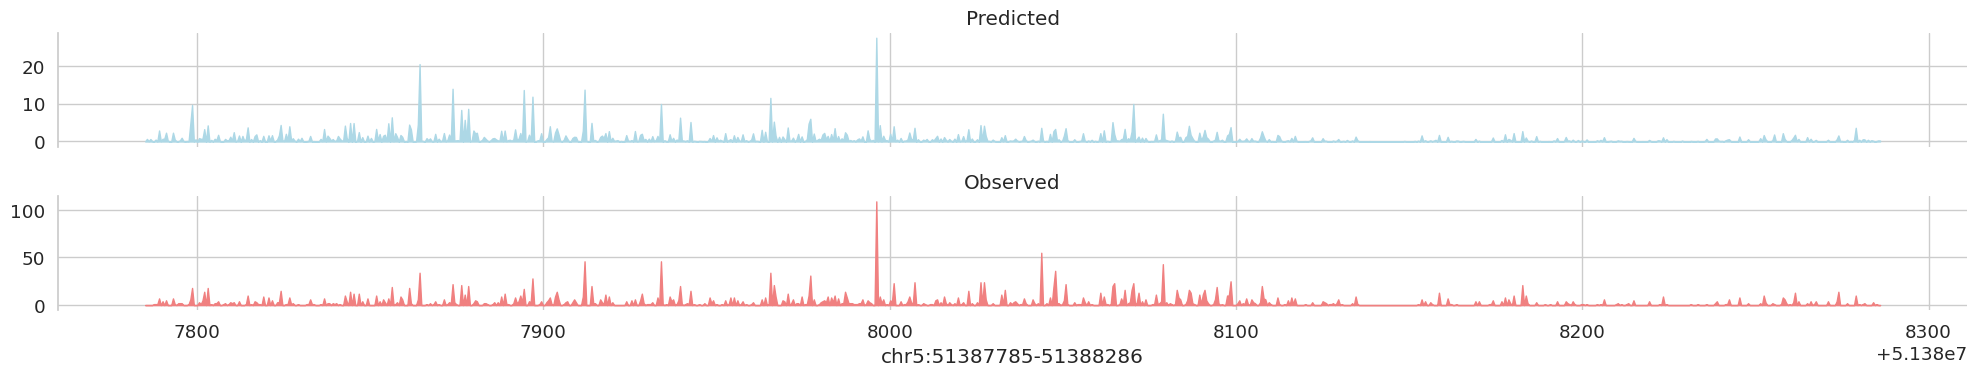

In [155]:
# Get data

idx = 10
example = candidates.iloc[idx]
true = y[idx].cpu().numpy().squeeze()
pred = preds[idx].cpu().numpy().squeeze()
chrom = example["chrom"]
chromStart = example["start"]
chromEnd = example["end"]
interval = dict(chrom=chrom, start=chromStart, end=chromEnd)
tracks = {
    "Predicted": pred,
    "Observed": true,
}
colors = {
    "Predicted": "lightblue",
    "Observed": "lightcoral",
}

with sns.plotting_context("notebook", font_scale=1.2):
    # Plot tracks
    plot_tracks(
        tracks=tracks,
        interval=interval,
        colors=colors,
        height=2,
    )

<Axes: xlabel='true_counts', ylabel='predicted_counts'>

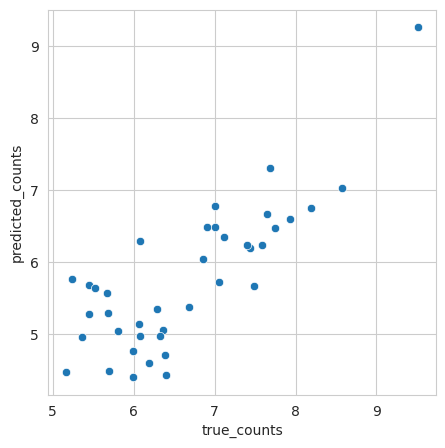

In [83]:
# scatter plot of true vs predicted counts


plt.figure(figsize=(5, 5))
sns.scatterplot(x="true_counts", y="predicted_counts", data=candidates)

In [62]:
candidates

,chrom,start,end,length,type,predicted_counts
0,chr5,51283789,51284290,501,peak,5.761421
1,chr5,51367003,51367504,501,peak,4.477687
2,chr5,51370118,51370619,501,peak,4.430048
3,chr5,51369372,51369873,501,peak,5.056140
4,chr5,51371805,51372306,501,peak,4.970246
5,chr5,51373826,51374327,501,peak,5.373733
6,chr5,51377127,51377628,501,peak,6.775398
7,chr5,51377650,51378151,501,peak,6.478411
8,chr5,51378733,51379234,501,peak,6.667976
9,chr5,51383078,51383579,501,peak,9.263675


In [63]:
from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear

In [64]:
dtype = torch.float64

In [65]:
count_wrapper = CountWrapper(ControlWrapper(arch)).cuda().eval()
X_attr_counts = deep_lift_shap(
    count_wrapper.type(dtype), 
    X.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)

  0%|          | 0/780 [00:00<?, ?it/s]

100%|██████████| 780/780 [00:28<00:00, 27.68it/s]


In [66]:
# Get profile attributions
profile_wrapper = ProfileWrapper(ControlWrapper(arch)).cuda().eval()
X_attr_profile = deep_lift_shap(
    profile_wrapper.type(dtype), 
    X.type(dtype),
    additional_nonlinear_ops={_ProfileLogitScaling: _nonlinear}, 
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)

100%|██████████| 780/780 [00:28<00:00, 27.50it/s]


In [67]:
X_attr_counts.shape

torch.Size([39, 4, 2114])

In [68]:
from tangermeme.seqlet import recursive_seqlets

In [69]:
counts_seqlets = recursive_seqlets(X_attr_counts.sum(dim=1))
counts_seqlets

,example_idx,start,end,attribution,p-value
0,27,1036,1044,0.585821,0.000075
1,20,1005,1029,-0.446013,0.000455
2,34,1000,1012,-0.203270,0.000520
3,9,1054,1066,0.562277,0.000541
4,15,939,944,-0.072144,0.000621
...,...,...,...,...,...
105,0,1074,1089,0.549398,0.007813
106,18,1293,1297,-0.028479,0.008080
107,35,1062,1066,0.076823,0.008240
108,0,1213,1217,0.070704,0.008413


In [70]:
profile_seqlets = recursive_seqlets(X_attr_profile.sum(dim=1))
profile_seqlets

,example_idx,start,end,attribution,p-value
0,31,1025,1034,0.574714,0.000154
1,26,629,641,-0.215793,0.000481
2,31,1075,1081,-0.125238,0.000620
3,31,1109,1123,-0.218075,0.000757
4,31,973,987,-0.240464,0.000782
...,...,...,...,...,...
101,11,701,705,-0.017614,0.008571
102,7,938,943,-0.023004,0.008733
103,36,1013,1019,0.040520,0.008935
104,9,1041,1045,0.026366,0.009383


In [71]:
counts_seqlets[counts_seqlets["example_idx"] == 38]

,example_idx,start,end,attribution,p-value
99,38,1048,1053,-0.036747,0.0074


In [72]:
profile_seqlets[profile_seqlets["example_idx"] == 38]

,example_idx,start,end,attribution,p-value
33,38,591,598,-0.055286,0.003444
50,38,557,561,-0.030264,0.004579
74,38,565,569,0.031830,0.006486
87,38,599,605,-0.030225,0.007041


In [73]:
profile_seqlets.sort_values("attribution", ascending=False)

,example_idx,start,end,attribution,p-value
9,26,1060,1082,0.713497,0.001237
0,31,1025,1034,0.574714,0.000154
8,27,1035,1052,0.318466,0.001181
51,31,1006,1021,0.316061,0.004615
7,31,1086,1096,0.227716,0.001083
...,...,...,...,...,...
42,26,651,671,-0.203297,0.003935
1,26,629,641,-0.215793,0.000481
3,31,1109,1123,-0.218075,0.000757
4,31,973,987,-0.240464,0.000782


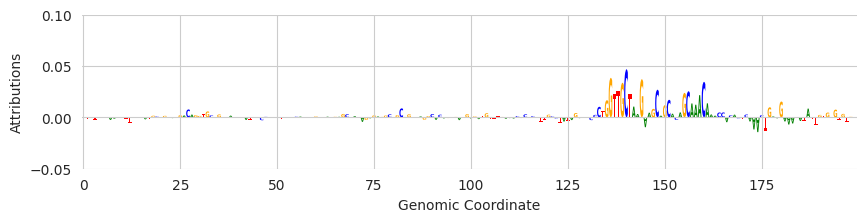

In [74]:
from matplotlib import pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_logo

plt.figure(figsize=(10, 2))
ax = plt.subplot(111)
plot_logo(X_attr_profile[27, :, 900:1100], ax=ax)

plt.xlabel("Genomic Coordinate")
plt.ylabel("Attributions")
plt.ylim(-0.05, 0.1)
plt.show()

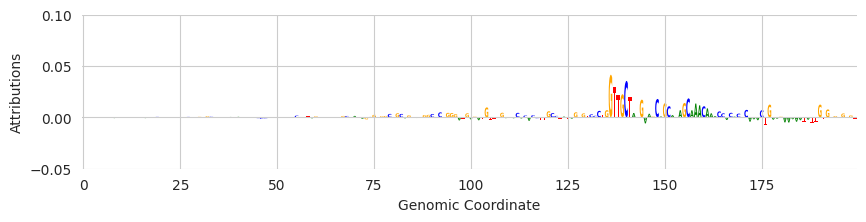

In [48]:
from matplotlib import pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_logo

plt.figure(figsize=(10, 2))
ax = plt.subplot(111)
plot_logo(X_attr_profile[27, :, 900:1100], ax=ax)

plt.xlabel("Genomic Coordinate")
plt.ylabel("Attributions")
plt.ylim(-0.05, 0.1)
plt.show()